In [11]:
!pip -q install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import os
import glob

# Data source:
# https://www.kaggle.com/datasets/profadept/shopping-behaviour-dataset

# Download the dataset
dataset_path = kagglehub.dataset_download(
    "profadept/shopping-behaviour-dataset"
)

# Find the CSV file
csv_files = glob.glob(
    os.path.join(dataset_path, "**", "*.csv"),
    recursive=True
)

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file was found.")

file_path = csv_files[0]

# Load the data
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip()

print("File used:", file_path)
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Using Colab cache for faster access to the 'shopping-behaviour-dataset' dataset.
File used: /kaggle/input/shopping-behaviour-dataset/shopping_behavior_updated.csv
Dataset shape: (3900, 18)
Columns:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


Records used for clustering: 3900

Features used for clustering:
['annual_spending', 'purchase_frequency', 'age']


,annual_spending,purchase_frequency,age,region
0,1378,26,55,Kentucky
1,1664,26,19,Maine
2,3796,52,50,Massachusetts
3,4680,52,21,Rhode Island
4,49,1,45,Oregon


,annual_spending,purchase_frequency,age
count,3900.000000,3900.000000,3900.000000
mean,1038.930513,17.471282,44.068462
std,1145.034309,16.809646,15.207589
min,20.000000,1.000000,18.000000
25%,188.000000,4.000000,31.000000
50%,572.000000,12.000000,44.000000
75%,1638.000000,26.000000,57.000000
max,5200.000000,52.000000,70.000000



Inertia values:
K=1: 11700.00
K=2: 6472.02
K=3: 4346.32
K=4: 3229.15
K=5: 2375.56

Silhouette scores:
K=2: 0.426
K=3: 0.392
K=4: 0.412
K=5: 0.443

Suggested number of clusters based on silhouette score: 5


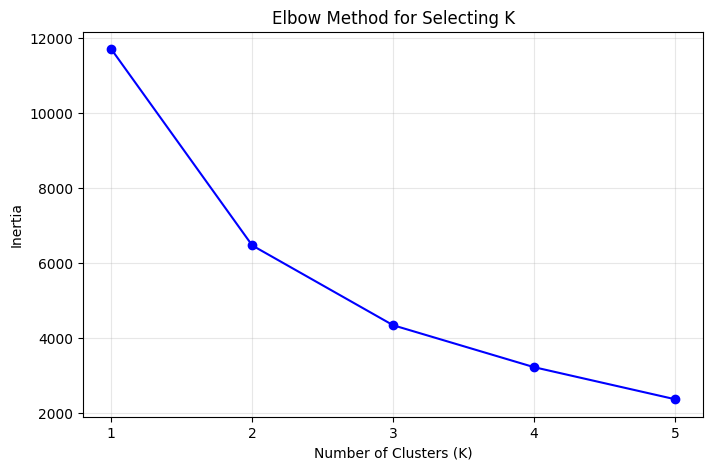

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Convert purchase-frequency labels into estimated purchases per year
frequency_map = {
    "Weekly": 52,
    "Bi-Weekly": 26,
    "Fortnightly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Every 3 Months": 4,
    "Annually": 1
}

# Clean important columns
df["age"] = pd.to_numeric(df["Age"], errors="coerce")

df["purchase_amount"] = pd.to_numeric(
    df["Purchase Amount (USD)"],
    errors="coerce"
)

df["frequency_label"] = (
    df["Frequency of Purchases"]
    .astype(str)
    .str.strip()
)

df["purchase_frequency"] = (
    df["frequency_label"].map(frequency_map)
)

df["region"] = (
    df["Location"]
    .astype(str)
    .str.strip()
)

# Estimate annual spending
# Assumption:
# Purchase Amount represents the average amount spent per purchase.
# Annual spending = purchase amount × estimated purchases per year.
df["annual_spending"] = (
    df["purchase_amount"] *
    df["purchase_frequency"]
)

# Select the features for clustering
features = [
    "annual_spending",
    "purchase_frequency",
    "age"
]

model_df = df[
    features + ["region"]
].dropna().copy()

# Remove impossible values
model_df = model_df[
    (model_df["age"] >= 18) &
    (model_df["age"] <= 100) &
    (model_df["annual_spending"] > 0) &
    (model_df["purchase_frequency"] > 0)
]

print("Records used for clustering:", len(model_df))
print("\nFeatures used for clustering:")
print(features)

display(model_df.head())
display(model_df[features].describe())

# Scale the numerical features
X = model_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate inertia for the elbow method
K = range(1, 6)
inertia = {}

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia[k] = kmeans.inertia_

# Calculate silhouette scores for K values from 2 to 5
silhouette_scores = {}

for k in range(2, 6):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    silhouette_scores[k] = silhouette_score(
        X_scaled,
        cluster_labels
    )

print("\nInertia values:")
for k, value in inertia.items():
    print(f"K={k}: {value:.2f}")

print("\nSilhouette scores:")
for k, value in silhouette_scores.items():
    print(f"K={k}: {value:.3f}")

suggested_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print(f"\nSuggested number of clusters based on silhouette score: {suggested_k}")

# Create the elbow plot
plt.figure(figsize=(8, 5))

plt.plot(
    list(inertia.keys()),
    list(inertia.values()),
    "bo-"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting K")
plt.xticks(list(K))
plt.grid(alpha=0.3)

plt.savefig(
    "elbow_plot.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Apply K-Means using the suggested K value
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

model_df["cluster"] = kmeans.fit_predict(X_scaled)

# Calculate average characteristics for each cluster
cluster_summary = model_df.groupby("cluster")[features].mean()

# Add cluster sizes
cluster_summary["customer_count"] = (
    model_df["cluster"].value_counts()
)

cluster_summary["percent_of_customers"] = (
    cluster_summary["customer_count"] /
    len(model_df) *
    100
)

# Find the most common region in each cluster
most_common_regions = (
    model_df.groupby("cluster")["region"]
    .agg(lambda values: values.mode().iloc[0])
)

cluster_summary["most_common_region"] = (
    most_common_regions
)

# Sort clusters by average annual spending
cluster_summary = cluster_summary.sort_values(
    by="annual_spending",
    ascending=False
)

print("Cluster Characteristics:")
display(cluster_summary.round(2))

# Create marketing strategies
median_spending = model_df["annual_spending"].median()
median_frequency = model_df["purchase_frequency"].median()

print("\nTargeted Marketing Strategies:")

for cluster, row in cluster_summary.iterrows():

    spending = row["annual_spending"]
    frequency = row["purchase_frequency"]

    print(f"\nCluster {cluster}")
    print(
        f"Average annual spending: ${spending:,.2f}"
    )
    print(
        f"Average purchase frequency: {frequency:.0f} purchases per year"
    )
    print(
        f"Most common region: {row['most_common_region']}"
    )

    if (
        spending >= median_spending and
        frequency >= median_frequency
    ):
        print(
            "Strategy: High-value loyal customers. "
            "Offer VIP rewards, exclusive promotions, and early access."
        )

    elif spending >= median_spending:
        print(
            "Strategy: High-spending customers who purchase less often. "
            "Use personalized reminders and high-value product bundles."
        )

    elif frequency >= median_frequency:
        print(
            "Strategy: Frequent buyers. "
            "Offer subscription plans, loyalty points, and bulk discounts."
        )

    else:
        print(
            "Strategy: Lower-engagement customers. "
            "Use introductory discounts and re-engagement campaigns."
        )

# Save the cluster assignments
model_df.to_csv(
    "customer_segments.csv",
    index=False
)

print(
    "\nCluster assignments saved to customer_segments.csv"
)

Cluster Characteristics:


,annual_spending,purchase_frequency,age,customer_count,percent_of_customers,most_common_region
cluster,,,,,,
2,3729.53,52.00,43.79,363,9.31,Louisiana
4,1583.42,29.84,57.14,636,16.31,Illinois
1,1569.76,29.39,30.34,629,16.13,West Virginia
3,311.94,5.20,31.04,1141,29.26,Montana
0,307.38,5.18,57.58,1131,29.00,Connecticut



Targeted Marketing Strategies:

Cluster 2
Average annual spending: $3,729.53
Average purchase frequency: 52 purchases per year
Most common region: Louisiana
Strategy: High-value loyal customers. Offer VIP rewards, exclusive promotions, and early access.

Cluster 4
Average annual spending: $1,583.42
Average purchase frequency: 30 purchases per year
Most common region: Illinois
Strategy: High-value loyal customers. Offer VIP rewards, exclusive promotions, and early access.

Cluster 1
Average annual spending: $1,569.76
Average purchase frequency: 29 purchases per year
Most common region: West Virginia
Strategy: High-value loyal customers. Offer VIP rewards, exclusive promotions, and early access.

Cluster 3
Average annual spending: $311.94
Average purchase frequency: 5 purchases per year
Most common region: Montana
Strategy: Lower-engagement customers. Use introductory discounts and re-engagement campaigns.

Cluster 0
Average annual spending: $307.38
Average purchase frequency: 5 purchas